In [4]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding,GRU,Dense,Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

In [5]:
df=pd.read_csv("spam.csv",encoding='latin-1')
df=df[['v1','v2']]
df.columns=['label','text']

print(f"Dataset Shape:{df.shape}")
print("\nClass Distribution:\n",df['label'].value_counts())

encoder=LabelEncoder()
df['label']=encoder.fit_transform(df['label'])

Dataset Shape:(5572, 2)

Class Distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
X_train,X_test,y_train,y_test=train_test_split(
    df['text'],df['label'],test_size=0.2,random_state=42,stratify=df['label']
)

MAX_WORDS=5000
MAX_LEN=50
EMBEDDING_DIM=64

tokenizer=Tokenizer(num_words=MAX_WORDS,oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq=tokenizer.texts_to_sequences(X_train)
X_test_seq=tokenizer.texts_to_sequences(X_test)

X_train_pad=pad_sequences(X_train_seq,maxlen=MAX_LEN,padding='post')
X_test_pad=pad_sequences(X_test_seq,maxlen=MAX_LEN,padding='post')

In [7]:
model=Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM
    ),
    GRU(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2,
        return_sequences=False
    ),
    Dense(units=32,activation='relu'),
    Dropout(0.3),
    Dense(units=1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 50, 64)              │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,073 (1.32 MB)

 Trainable params: 347,073 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("\nTraining the GRU Model...")
history = model.fit(
    X_train_pad, 
    y_train, 
    epochs=5,                
    batch_size=32, 
    validation_split=0.1,    
    verbose=1
)
print("\nEvaluating Model on Test Data...")
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int)


Training the GRU Model...
Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8636 - loss: 0.4254 - val_accuracy: 0.8453 - val_loss: 0.4360
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8681 - loss: 0.4063 - val_accuracy: 0.8453 - val_loss: 0.4329
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8681 - loss: 0.4036 - val_accuracy: 0.8453 - val_loss: 0.4399
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8681 - loss: 0.3961 - val_accuracy: 0.8453 - val_loss: 0.4328
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8681 - loss: 0.4015 - val_accuracy: 0.8453 - val_loss: 0.4347

Evaluating Model on Test Data...
Test Loss: 0.3942
Test Accuracy: 86.64%
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step



Classification Report:
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       966
        Spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



C:\Users\gnana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gnana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gnana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

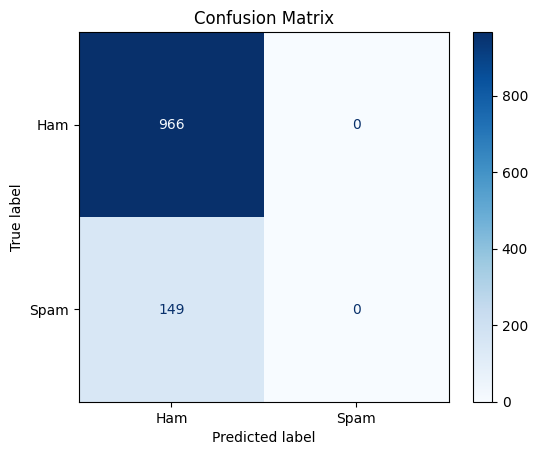

In [9]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [10]:
def filter_incoming_sms(message_text):
    seq = tokenizer.texts_to_sequences([message_text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    
    
    probability = model.predict(padded, verbose=0)[0][0]
    
    if probability > 0.5:
        return f"[SPAM ALERT ({probability*100:.1f}% Match)] -> Sent to Spam Folder."
    else:
        return f"[INBOX (Legitimate)] -> {message_text}"

test_msg_1 = "ham,Sorry, I call later in meeting.,,,"
print(filter_incoming_sms(test_msg_1))

[INBOX (Legitimate)] -> ham,Sorry, I call later in meeting.,,,
